In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# https://www.kaggle.com/datasets/tamber/steam-video-games
dataset = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/steam-200k.csv',
    header=None,
    names=['user-id', 'game-title', 'behavior-name', 'value', 'timestamp'],
)
dataset

,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
...,...,...,...,...,...
199995,128470551,Titan Souls,play,1.5,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0
199997,128470551,Grand Theft Auto Vice City,play,1.5,0
199998,128470551,RUSH,purchase,1.0,0


In [ ]:
# Фильтрация покупок
purchases = dataset[dataset['behavior-name'] == 'purchase'].drop_duplicates(['user-id', 'game-title'])
purchases


,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
2,151603712,Fallout 4,purchase,1.0,0
4,151603712,Spore,purchase,1.0,0
6,151603712,Fallout New Vegas,purchase,1.0,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
...,...,...,...,...,...
199990,128470551,Fallen Earth,purchase,1.0,0
199992,128470551,Magic Duels,purchase,1.0,0
199994,128470551,Titan Souls,purchase,1.0,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0


In [ ]:
transactions = purchases.groupby('user-id')['game-title'].apply(list).tolist()
print(f"Количество транзакций: {len(transactions)}")
print("Пример транзакции:")
print(transactions[0])

Количество транзакций: 12393
Пример транзакции:
['Cities Skylines', 'Deus Ex Human Revolution', 'Portal 2', 'Alien Swarm', 'Team Fortress 2', 'Dota 2', 'Counter-Strike', 'Counter-Strike Source', 'Day of Defeat', 'Deathmatch Classic', 'Half-Life', 'Half-Life 2', 'Half-Life 2 Deathmatch', 'Half-Life 2 Episode One', 'Half-Life 2 Episode Two', 'Half-Life 2 Lost Coast', 'Half-Life Blue Shift', 'Half-Life Opposing Force', 'Portal', 'Ricochet', 'Team Fortress Classic']


5155


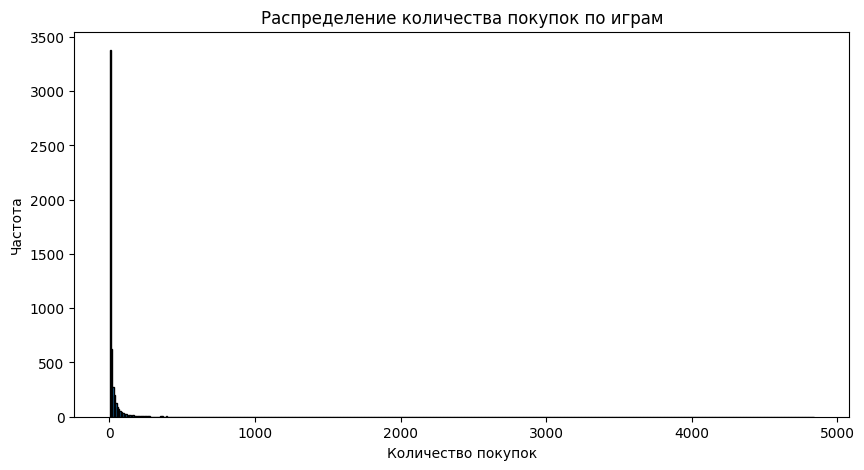

Топ-10 самых популярных игр:
Dota 2: 4841 покупок
Team Fortress 2: 2323 покупок
Unturned: 1563 покупок
Counter-Strike Global Offensive: 1412 покупок
Half-Life 2 Lost Coast: 981 покупок
Counter-Strike Source: 978 покупок
Left 4 Dead 2: 951 покупок
Counter-Strike: 856 покупок
Warframe: 847 покупок
Half-Life 2 Deathmatch: 823 покупок


In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import itertools

# Статистика по играм
game_counts = Counter(itertools.chain.from_iterable(transactions))
print(len(game_counts))
plt.figure(figsize=(10, 5))
plt.hist(list(game_counts.values()), bins=500, edgecolor='black')
plt.title('Распределение количества покупок по играм')
plt.xlabel('Количество покупок')
plt.ylabel('Частота')
plt.show()

print("Топ-10 самых популярных игр:")
for game, count in game_counts.most_common(10):
    print(f"{game}: {count} покупок")

In [ ]:
class TreeNode:
    def __init__(self, name, count, parent):
        self.name = name
        self.count = count
        self.parent = parent
        self.children = {}
        self.next = None

    def increment(self, count):
        self.count += count

def create_tree(transactions, min_support):
    header_table = defaultdict(int)
    for trans in transactions:
        for item in trans:
            header_table[item] += 1

    header_table = {k: v for k, v in header_table.items() if v >= min_support}
    frequent_items = set(header_table.keys())

    if not frequent_items:
        return None, None

    for k in header_table:
        header_table[k] = [header_table[k], None]

    root = TreeNode('Null', 1, None)

    for trans in transactions:
        filtered_items = [item for item in trans if item in frequent_items]
        filtered_items.sort(key=lambda x: header_table[x][0], reverse=True)
        current_node = root
        for item in filtered_items:
            current_node = update_tree(item, current_node, header_table, 1)

    return root, header_table

def update_tree(item, node, header_table, count):
    if item in node.children:
        node.children[item].increment(count)
    else:
        new_node = TreeNode(item, count, node)
        node.children[item] = new_node
        update_header_table(item, new_node, header_table)

    return node.children[item]

def update_header_table(item, new_node, header_table):
    if header_table[item][1] is None:
        header_table[item][1] = new_node
    else:
        current = header_table[item][1]
        while current.next is not None:
            current = current.next
        current.next = new_node

min_support = 0.01 * len(transactions)
root, header_table = create_tree(transactions, min_support)
print("Построено FP-дерево с минимальной поддержкой", min_support)
print("Размер header_table", len(header_table))
header_table

Построено FP-дерево с минимальной поддержкой 123.93
Размер header_table 197


{'Deus Ex Human Revolution': [163, <__main__.TreeNode at 0x785eab00c440>],
 'Portal 2': [544, <__main__.TreeNode at 0x785eaadc00e0>],
 'Alien Swarm': [289, <__main__.TreeNode at 0x785eab00c500>],
 'Team Fortress 2': [2323, <__main__.TreeNode at 0x785eaadc0110>],
 'Dota 2': [4841, <__main__.TreeNode at 0x785eab423260>],
 'Counter-Strike': [856, <__main__.TreeNode at 0x785eaadc2e10>],
 'Counter-Strike Source': [978, <__main__.TreeNode at 0x785eaadc1130>],
 'Day of Defeat': [534, <__main__.TreeNode at 0x785eaadf1e80>],
 'Deathmatch Classic': [524, <__main__.TreeNode at 0x785eaadf1280>],
 'Half-Life': [388, <__main__.TreeNode at 0x785eab00ccb0>],
 'Half-Life 2': [639, <__main__.TreeNode at 0x785eaadc1430>],
 'Half-Life 2 Deathmatch': [823, <__main__.TreeNode at 0x785eaadc0830>],
 'Half-Life 2 Episode One': [394, <__main__.TreeNode at 0x785eab00c1a0>],
 'Half-Life 2 Episode Two': [365, <__main__.TreeNode at 0x785eab00c890>],
 'Half-Life 2 Lost Coast': [981, <__main__.TreeNode at 0x785eaadc0

In [ ]:
# Альтернативный вариант: визуализация только самых популярных ветвей
def print_popular_branches(node, min_count=500, max_depth=4, current_depth=0, prefix=""):
    """Визуализация только ветвей с высокой частотой"""
    if current_depth > max_depth or node is None:
        return

    # Пропускаем узлы с низкой частотой (кроме корня)
    if current_depth > 0 and node.count < min_count:
        return

    # Вывод текущего узла
    if current_depth == 0:
        print("Самые популярные ветви FP-дерева:")
        print(f"   {node.name} (count: {node.count})")
    else:
        connector = "├── " if current_depth == 1 else "│   └── "
        print(prefix + connector + f"{node.name} (count: {node.count})")

    # Сортируем детей по частоте и берем топ
    sorted_children = sorted(node.children.values(), key=lambda x: x.count, reverse=True)
    new_prefix = prefix + ("│   " if current_depth >= 1 else "    ")

    # Рекурсивный обход дочерних элементов
    for i, child in enumerate(sorted_children):
        if child.count >= min_count / (current_depth + 1):  # Динамический порог
            is_last = i == len(sorted_children) - 1
            child_prefix = new_prefix if not is_last else new_prefix.replace("│", " ")
            print_popular_branches(child, min_count, max_depth, current_depth + 1, child_prefix)

print("\n" + "="*50)
print_popular_branches(root, min_count=200, max_depth=4)


🎮 Самые популярные ветви FP-дерева:
   Null (count: 1)
    ├── Dota 2 (count: 4841)
    │   │   └── Team Fortress 2 (count: 723)
    │   │   │   └── Unturned (count: 310)
    │   │   │   │   └── Counter-Strike Global Offensive (count: 206)
    │   │   └── Unturned (count: 251)
    ├── Team Fortress 2 (count: 1600)
    │   │   └── Unturned (count: 317)
    ├── Unturned (count: 685)
    ├── Half-Life 2 Lost Coast (count: 493)
    │   │   └── Counter-Strike Source (count: 319)
    │   │   │   └── Half-Life 2 Deathmatch (count: 238)
    ├── Counter-Strike Global Offensive (count: 401)
    ├── Counter-Strike (count: 297)
    │   │   └── Counter-Strike Condition Zero (count: 204)
            │   └── Counter-Strike Condition Zero Deleted Scenes (count: 204)


In [ ]:
def mine_tree(header_table, min_support, prefix, frequent_itemsets):
    sorted_items = [item[0] for item in sorted(header_table.items(), key=lambda x: x[1][0])]
    for item in sorted_items:
        new_prefix = prefix.copy()
        new_prefix.add(item)
        support = header_table[item][0]
        frequent_itemsets[tuple(sorted(new_prefix))] = support

        conditional_patterns = find_prefix_paths(item, header_table)
        _, conditional_header = create_tree(conditional_patterns, min_support)

        if conditional_header is not None:
            mine_tree(conditional_header, min_support, new_prefix, frequent_itemsets)

def find_prefix_paths(item, header_table):
    paths = []
    node = header_table[item][1]
    while node is not None:
        prefix_path = []
        ascend_tree(node, prefix_path)
        if len(prefix_path) > 1:
            paths.append(prefix_path[1:])
        node = node.next
    return paths

def ascend_tree(node, prefix_path):
    if node.parent is not None:
        prefix_path.append(node.name)
        ascend_tree(node.parent, prefix_path)

frequent_itemsets = {}
mine_tree(header_table, min_support, set(), frequent_itemsets)
print(f"Найдено {len(frequent_itemsets)} часто встречающихся наборов")

# Топ-10 наборов
top_itemsets = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:10]
print("Топ-10 часто встречающихся наборов:")
for itemset, support in top_itemsets:
    print(f"{itemset}: {support}")

Найдено 807 часто встречающихся наборов
Топ-10 часто встречающихся наборов:
('Dota 2',): 4841
('Team Fortress 2',): 2323
('Unturned',): 1563
('Counter-Strike Global Offensive',): 1412
('Half-Life 2 Lost Coast',): 981
('Counter-Strike Source',): 978
('Left 4 Dead 2',): 951
('Counter-Strike',): 856
('Warframe',): 847
('Half-Life 2 Deathmatch',): 823


In [ ]:
def generate_rules(frequent_itemsets, min_confidence):
    rules = []
    for itemset, support in frequent_itemsets.items():
        if len(itemset) > 1:
            for i in range(1, len(itemset)):
                for antecedent in itertools.combinations(itemset, i):
                    antecedent = tuple(sorted(antecedent))
                    consequent = tuple(sorted(set(itemset) - set(antecedent)))

                    if antecedent in frequent_itemsets:
                        confidence = support / frequent_itemsets[antecedent]
                        if confidence >= min_confidence:
                            # Рассчитываем lift
                            consequent_support = frequent_itemsets.get(consequent, 0)
                            if consequent_support > 0:
                                lift = confidence / consequent_support
                            else:
                                lift = 0
                            rules.append((antecedent, consequent, confidence, support, lift))
    return rules

min_confidence = 0.8
rules = generate_rules(frequent_itemsets, min_confidence)
print(f"Сгенерировано {len(rules)} правил с минимальной уверенностью {min_confidence}")

rules.sort(key=lambda x: x[2], reverse=True)
print("Топ-50 правил по уверенности:")
for ant, cons, conf, supp, lift in rules[:50]:
    print(f"{ant} => {cons} (conf: {conf:.3f}, supp: {supp}, lift: {lift:.6f})")

Сгенерировано 68 правил с минимальной уверенностью 0.8
Топ-50 правил по уверенности:
('Company of Heroes Tales of Valor',) => ('Company of Heroes (New Steam Version)',) (conf: 1.000, supp: 129, lift: 0.005208)
('Company of Heroes Opposing Fronts',) => ('Company of Heroes (New Steam Version)',) (conf: 1.000, supp: 144, lift: 0.005208)
('Company of Heroes',) => ('Company of Heroes (New Steam Version)',) (conf: 0.994, supp: 178, lift: 0.005179)
('Borderlands DLC The Zombie Island of Dr. Ned',) => ('Borderlands',) (conf: 0.993, supp: 138, lift: 0.005425)
('Borderlands DLC The Secret Armory of General Knoxx',) => ('Borderlands',) (conf: 0.993, supp: 137, lift: 0.005425)
("Borderlands DLC Mad Moxxi's Underdome Riot",) => ('Borderlands DLC The Secret Armory of General Knoxx',) (conf: 0.993, supp: 134, lift: 0.007193)
("Borderlands DLC Mad Moxxi's Underdome Riot",) => ('Borderlands',) (conf: 0.993, supp: 134, lift: 0.005424)
('Borderlands DLC Claptraps New Robot Revolution',) => ('Borderlands 

In [ ]:
import time
import numpy as np

def evaluate_parameters_with_lift(transactions, support_values, confidence_values):
    results = []

    for min_support in support_values:
        min_support_orig = min_support
        min_support *= len(transactions)

        start_time = time.time()
        print(min_support)
        root, header_table = create_tree(transactions, min_support)
        print(len(header_table))
        tree_time = time.time() - start_time

        if root is None:
            continue

        start_time = time.time()
        frequent_itemsets = {}
        mine_tree(header_table, min_support, set(), frequent_itemsets)
        mining_time = time.time() - start_time

        for min_confidence in confidence_values:
            start_time = time.time()
            rules = generate_rules(frequent_itemsets, min_confidence)
            rules_time = time.time() - start_time

            avg_confidence = np.mean([rule[2] for rule in rules]) if rules else 0
            avg_support = np.mean([rule[3] for rule in rules]) if rules else 0
            avg_lift = np.mean([rule[4] for rule in rules]) if rules else 0

            results.append({
                'min_support': min_support_orig,
                'min_confidence': min_confidence,
                'tree_time': tree_time,
                'mining_time': mining_time,
                'rules_time': rules_time,
                'total_time': tree_time + mining_time + rules_time,
                'itemsets_count': len(frequent_itemsets),
                'rules_count': len(rules),
                'avg_confidence': avg_confidence,
                'avg_support': avg_support,
                'avg_lift': avg_lift
            })

            print(f"Support: {min_support_orig}, Confidence: {min_confidence}, "
                  f"Rules: {len(rules)}, Avg Lift: {avg_lift:.5f}, Time: {tree_time + mining_time + rules_time:.2f}s")

    return pd.DataFrame(results)

support_values = [0.005 + 0.0025 * i for i in range(0, 8)]
confidence_values = [0.65 + 0.025 * i for i in range(0, 14)]

results_df_lift = evaluate_parameters_with_lift(transactions, support_values, confidence_values)

61.965
446
Support: 0.005, Confidence: 0.65, Rules: 3249, Avg Lift: 0.00222, Time: 2.50s
Support: 0.005, Confidence: 0.675, Rules: 2986, Avg Lift: 0.00228, Time: 2.50s
Support: 0.005, Confidence: 0.7000000000000001, Rules: 2677, Avg Lift: 0.00238, Time: 2.50s
Support: 0.005, Confidence: 0.7250000000000001, Rules: 2451, Avg Lift: 0.00248, Time: 2.50s
Support: 0.005, Confidence: 0.75, Rules: 2227, Avg Lift: 0.00258, Time: 2.50s
Support: 0.005, Confidence: 0.775, Rules: 1990, Avg Lift: 0.00268, Time: 2.50s
Support: 0.005, Confidence: 0.8, Rules: 1782, Avg Lift: 0.00278, Time: 2.50s
Support: 0.005, Confidence: 0.8250000000000001, Rules: 1593, Avg Lift: 0.00286, Time: 2.50s
Support: 0.005, Confidence: 0.8500000000000001, Rules: 1394, Avg Lift: 0.00301, Time: 2.50s
Support: 0.005, Confidence: 0.875, Rules: 1219, Avg Lift: 0.00313, Time: 2.50s
Support: 0.005, Confidence: 0.9, Rules: 1007, Avg Lift: 0.00332, Time: 2.50s
Support: 0.005, Confidence: 0.925, Rules: 831, Avg Lift: 0.00342, Time: 2.

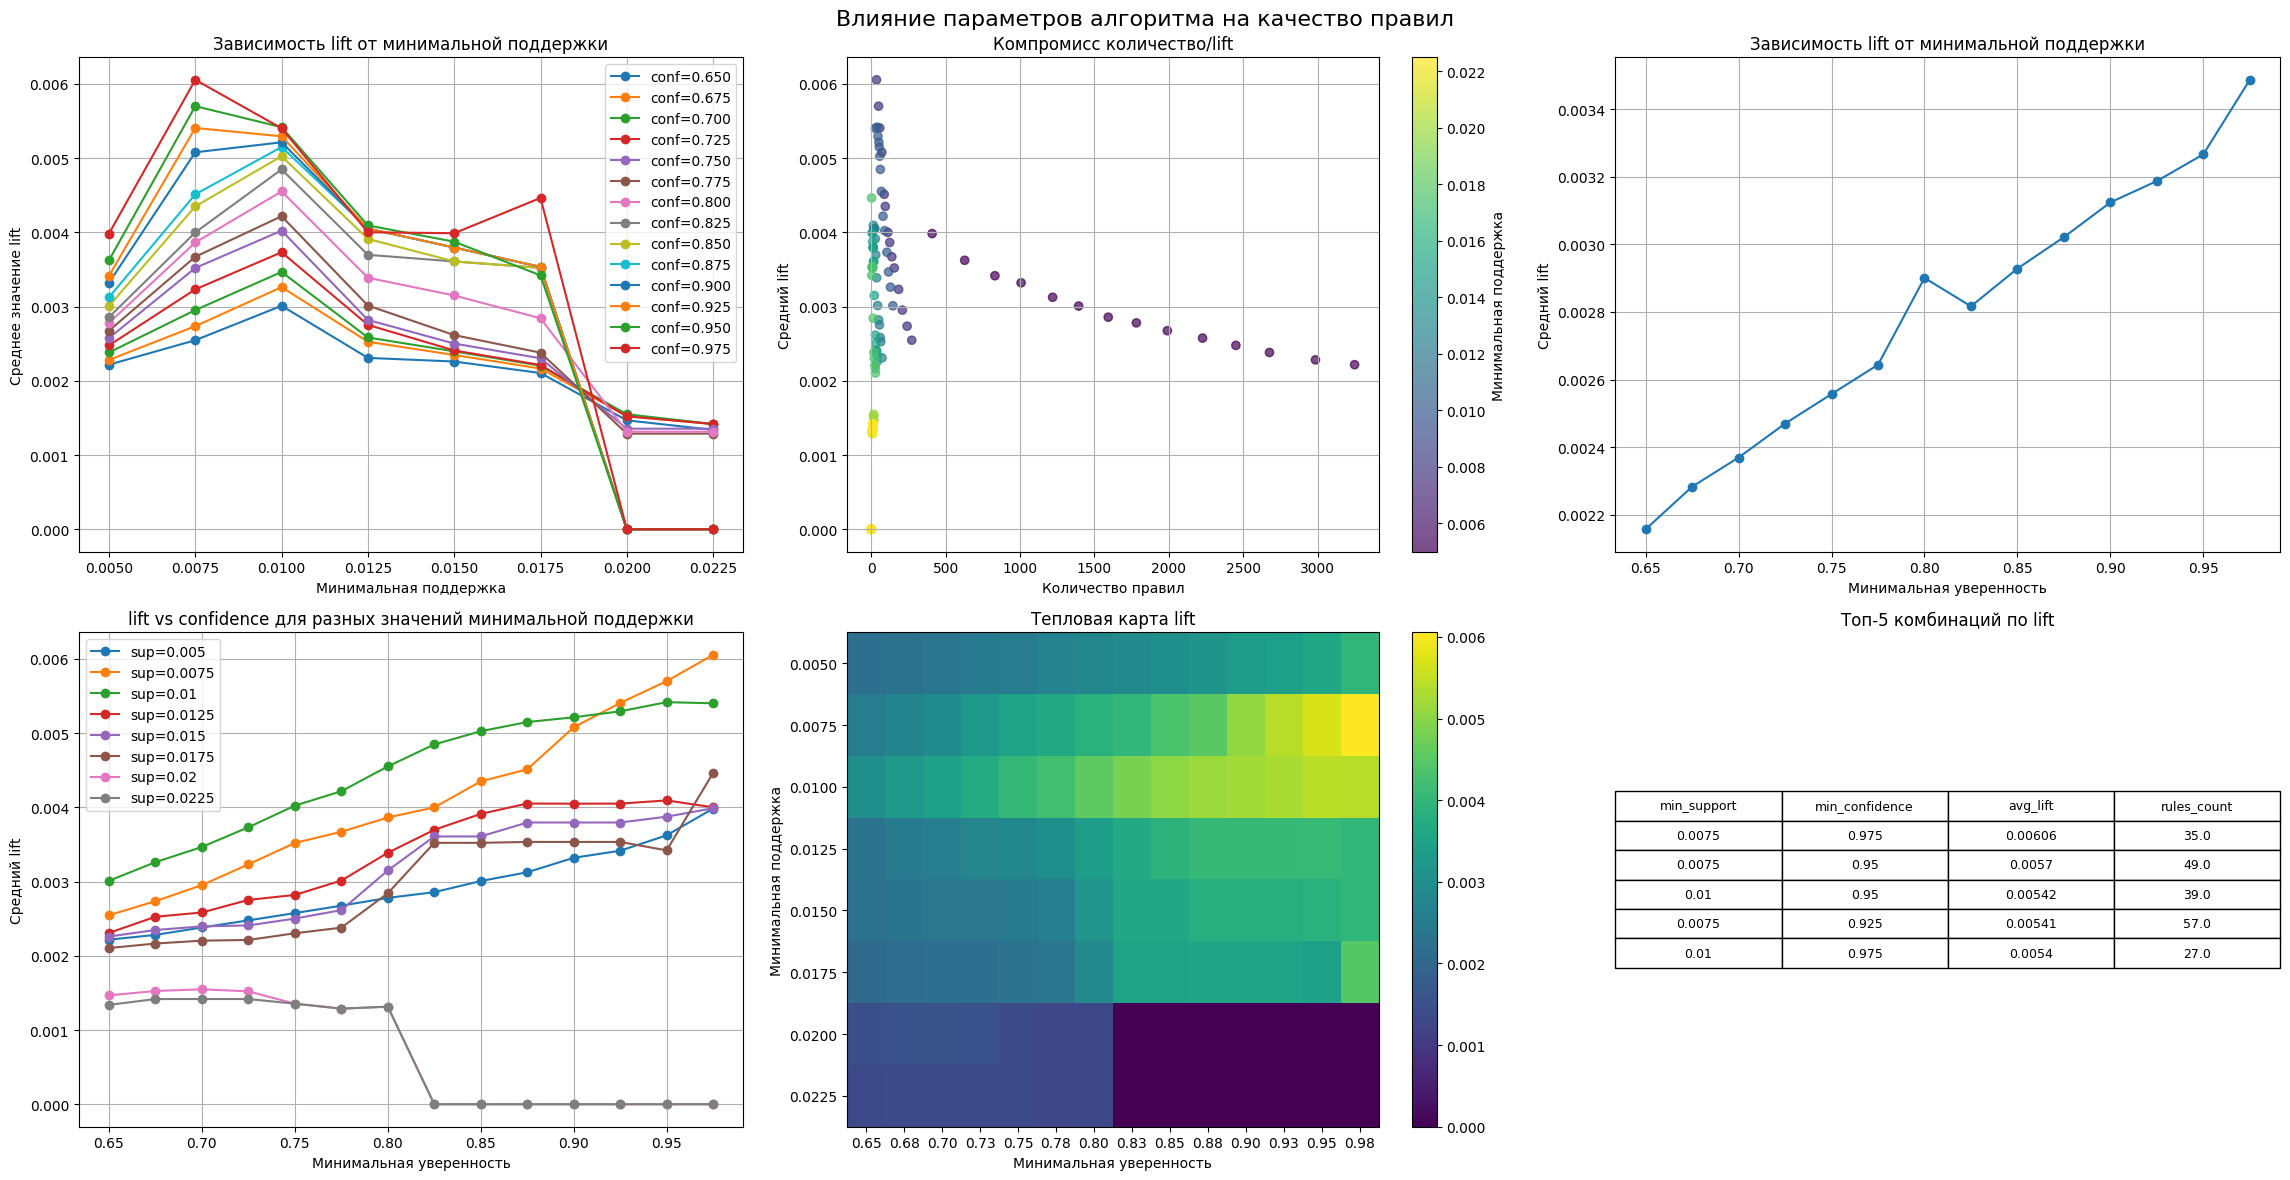

In [ ]:
# Визуализация результатов с акцентом на lift
fig, axes = plt.subplots(2, 3, figsize=(23, 12))
fig.suptitle('Влияние параметров алгоритма на качество правил', fontsize=16)

# Средний lift в зависимости от min_support
for confidence in confidence_values:
    subset = results_df_lift[results_df_lift['min_confidence'] == confidence]
    axes[0, 0].plot(subset['min_support'], subset['avg_lift'], 'o-', label=f'conf={confidence:.3f}')
axes[0, 0].set_xlabel('Минимальная поддержка')
axes[0, 0].set_ylabel('Среднее значение lift')
axes[0, 0].set_title('Зависимость lift от минимальной поддержки')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Компромисс между количеством правил и lift
scatter = axes[0, 1].scatter(results_df_lift['rules_count'], results_df_lift['avg_lift'],
                            c=results_df_lift['min_support'], cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel('Количество правил')
axes[0, 1].set_ylabel('Средний lift')
axes[0, 1].set_title('Компромисс количество/lift')
plt.colorbar(scatter, ax=axes[0, 1], label='Минимальная поддержка')
axes[0, 1].grid(True)

# Зависимость lift от min_confidence
lift_by_confidence = results_df_lift.groupby('min_confidence')['avg_lift'].mean()
axes[0, 2].plot(lift_by_confidence.index, lift_by_confidence.values, 'o-')
axes[0, 2].set_xlabel('Минимальная уверенность')
axes[0, 2].set_ylabel('Средний lift')
axes[0, 2].set_title('Зависимость lift от минимальной поддержки')
axes[0, 2].grid(True)

# Сравнение lift и confidence
for support in support_values:
    subset = results_df_lift[results_df_lift['min_support'] == support]
    axes[1, 0].plot(subset['min_confidence'], subset['avg_lift'], 'o-', label=f'sup={support:.4}')
axes[1, 0].set_xlabel('Минимальная уверенность')
axes[1, 0].set_ylabel('Средний lift')
axes[1, 0].set_title('lift vs confidence для разных значений минимальной поддержки')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Тепловая карта зависимости lift от параметров
pivot_table = results_df_lift.pivot_table(values='avg_lift',
                                         index='min_support',
                                         columns='min_confidence')
im = axes[1, 1].imshow(pivot_table.values, cmap='viridis', aspect='auto')
axes[1, 1].set_xticks(range(len(pivot_table.columns)))
axes[1, 1].set_xticklabels([f'{c:.2f}' for c in pivot_table.columns])
axes[1, 1].set_yticks(range(len(pivot_table.index)))
axes[1, 1].set_yticklabels([f'{c:.4f}' for c in pivot_table.index])
axes[1, 1].set_xlabel('Минимальная уверенность')
axes[1, 1].set_ylabel('Минимальная поддержка')
axes[1, 1].set_title('Тепловая карта lift')
plt.colorbar(im, ax=axes[1, 1])

# Лучшие комбинации параметров по lift
best_by_lift = results_df_lift.nlargest(5, 'avg_lift')[['min_support', 'min_confidence', 'avg_lift', 'rules_count']]
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=best_by_lift.round(5).values,
                        colLabels=best_by_lift.columns,
                        cellLoc='center',
                        loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
axes[1, 2].set_title('Топ-5 комбинаций по lift')

plt.tight_layout()
plt.show()

In [ ]:
# Анализ оптимальных параметров на основе lift
print("Анализ оптимальных параметров на основе Lift:")
print(f"Максимальный средний lift: {results_df_lift['avg_lift'].max():.6f}")
print(f"Минимальный средний lift: {results_df_lift['avg_lift'].min():.6f}")

# Находим оптимальные параметры на основе lift
results_df_lift['lift_score'] = results_df_lift['avg_lift'] # * np.log1p(results_df_lift['rules_count']) / results_df_lift['total_time']
best_params_lift = results_df_lift.loc[results_df_lift['lift_score'].idxmax()]

print("\nРекомендуемые параметры (на основе Lift):")
print(f"Min Support: {best_params_lift['min_support']}")
print(f"Min Confidence: {best_params_lift['min_confidence']}")
print(f"Ожидаемое количество правил: {int(best_params_lift['rules_count'])}")
print(f"Ожидаемый средний lift: {best_params_lift['avg_lift']:.5f}")
print(f"Ожидаемое время выполнения: {best_params_lift['total_time']:.2f} сек")

# Анализ правил с высоким lift
print("\nПравила с высоким lift обычно указывают на:")
print("- Сильные ассоциации между играми")
print("- Наборы игр, которые часто покупаются вместе")
print("- Реальные поведенческие паттерны пользователей")
print("- Потенциально полезные рекомендации")

Анализ оптимальных параметров на основе Lift:
Максимальный средний lift: 0.006056
Минимальный средний lift: 0.000000

Рекомендуемые параметры (на основе Lift):
Min Support: 0.0075
Min Confidence: 0.9750000000000001
Ожидаемое количество правил: 35
Ожидаемый средний lift: 0.00606
Ожидаемое время выполнения: 1.09 сек

Правила с высоким lift обычно указывают на:
- Сильные ассоциации между играми
- Наборы игр, которые часто покупаются вместе
- Реальные поведенческие паттерны пользователей
- Потенциально полезные рекомендации


In [ ]:
# Детальный анализ для рекомендованных параметров на основе lift
recommended_support_lift = 0.01 # int(best_params_lift['min_support'])
recommended_confidence_lift = 0.8 # best_params_lift['min_confidence']

print(f"Детальный анализ для min_support={recommended_support_lift}, min_confidence={recommended_confidence_lift}:")

# Строим дерево с рекомендованными параметрами
root, header_table = create_tree(transactions, recommended_support_lift * len(transactions))
frequent_itemsets = {}
mine_tree(header_table, recommended_support_lift * len(transactions), set(), frequent_itemsets)
rules = generate_rules(frequent_itemsets, recommended_confidence_lift)
print(f"Количество правил: {len(rules)}")

# Топ-10 правил по lift
rules.sort(key=lambda x: x[4], reverse=True)
print("\nТоп-10 правил по Lift:")
for i, (ant, cons, conf, supp, lift) in enumerate(rules[:10]):
    supp /= len(transactions)
    print(f"{i+1}. {ant} => {cons}")
    print(f"   Confidence: {conf:.5f}, Support: {supp}, Lift: {lift:.6f}")
    print()

Детальный анализ для min_support=0.01, min_confidence=0.8:
Количество правил: 68

Топ-10 правил по Lift:
1. ('Starbound',) => ('Starbound - Unstable',)
   Confidence: 0.98507, Support: 0.01065117404986686, Lift: 0.007351

2. ('Starbound - Unstable',) => ('Starbound',)
   Confidence: 0.98507, Support: 0.01065117404986686, Lift: 0.007351

3. ('Borderlands DLC Claptraps New Robot Revolution',) => ("Borderlands DLC Mad Moxxi's Underdome Riot",)
   Confidence: 0.98438, Support: 0.010167029774872912, Lift: 0.007292

4. ("Borderlands DLC Mad Moxxi's Underdome Riot",) => ('Borderlands DLC Claptraps New Robot Revolution',)
   Confidence: 0.93333, Support: 0.010167029774872912, Lift: 0.007292

5. ("Borderlands DLC Mad Moxxi's Underdome Riot",) => ('Borderlands DLC The Secret Armory of General Knoxx',)
   Confidence: 0.99259, Support: 0.010812555474864843, Lift: 0.007193

6. ('Borderlands DLC The Secret Armory of General Knoxx',) => ("Borderlands DLC Mad Moxxi's Underdome Riot",)
   Confidence: 0

In [ ]:
# Функция для получения рекомендаций на основе заданной игры
def get_recommendations(target_game, rules, top_n=10):
    """
    Возвращает рекомендации для заданной игры
    target_game: название игры для которой ищем рекомендации
    rules: список правил ассоциации
    top_n: количество возвращаемых рекомендаций
    """
    recommendations = []

    for antecedent, consequent, confidence, support, lift in rules:
        # Если целевая игра в антецеденте (левой части правила)
        if target_game in antecedent:
            # Для каждого элемента в консеквенте (правой части)
            for game in consequent:
                # Исключаем саму целевую игру
                if game != target_game:
                    recommendations.append({
                        'game': game,
                        'confidence': confidence,
                        'support': support,
                        'lift': lift,
                        'rule_type': 'direct'
                    })

        # Если целевая игра в консеквенте, можем инвертировать правило
        elif target_game in consequent:
            for game in antecedent:
                if game != target_game:
                    recommendations.append({
                        'game': game,
                        'confidence': confidence,
                        'support': support,
                        'lift': lift,
                        'rule_type': 'inverse'
                    })

    # Создаем DataFrame из рекомендаций
    if recommendations:
        rec_df = pd.DataFrame(recommendations)

        # Группируем по игре и усредняем метрики
        grouped_rec = rec_df.groupby('game').agg({
            'confidence': 'mean',
            'support': 'mean',
            'lift': 'mean',
            'rule_type': lambda x: ', '.join(set(x))
        }).reset_index()

        # Сортируем по lift (приоритет) и confidence
        grouped_rec = grouped_rec.sort_values(['lift', 'confidence'], ascending=False)

        return grouped_rec.head(top_n)
    else:
        return pd.DataFrame()

# Задаем целевую игру
target_game = "Half-Life 2"

# Получаем рекомендации
recommendations = get_recommendations(target_game, rules)

print(f"Рекомендации для игры '{target_game}':")
print("=" * 60)

if not recommendations.empty:
    for i, (_, row) in enumerate(recommendations.iterrows(), 1):
        print(f"{i}. {row['game']}")
        print(f"   Lift: {row['lift']:.6f}, Confidence: {row['confidence']:.3f}, Support: {row['support']:.1f}")
        print(f"   Тип правила: {row['rule_type']}")
        print()
else:
    print("Не найдено рекомендаций для этой игры.")

Рекомендации для игры 'Half-Life 2':
1. Half-Life Source
   Lift: 0.001293, Confidence: 0.826, Support: 157.0
   Тип правила: inverse

2. Half-Life 2 Episode Two
   Lift: 0.001256, Confidence: 0.803, Support: 293.0
   Тип правила: inverse



/tmp/ipython-input-616642503.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


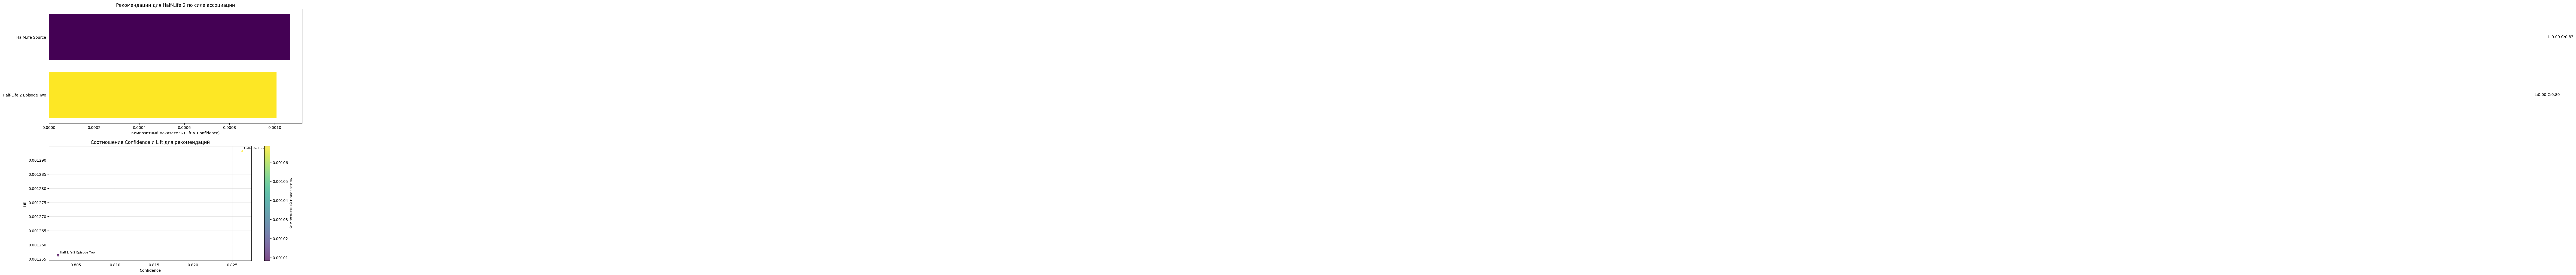

In [ ]:
# Визуализация рекомендаций
if not recommendations.empty:
    plt.figure(figsize=(12, 12))

    # Создаем composite score для ранжирования
    recommendations['score'] = recommendations['lift'] * recommendations['confidence']

    # График рекомендаций по lift и confidence
    plt.subplot(2, 1, 1)
    colors = plt.cm.viridis(np.linspace(0, 1, len(recommendations)))
    bars = plt.barh(range(len(recommendations)), recommendations['score'], color=colors)
    plt.yticks(range(len(recommendations)), recommendations['game'])
    plt.xlabel('Композитный показатель (Lift × Confidence)')
    plt.title(f'Рекомендации для {target_game} по силе ассоциации')
    plt.gca().invert_yaxis()

    # Добавляем значения на график
    for i, (score, lift, conf) in enumerate(zip(recommendations['score'],
                                               recommendations['lift'],
                                               recommendations['confidence'])):
        plt.text(score + 0.01, i, f'L:{lift:.2f} C:{conf:.2f}', va='center')

    # Scatter plot lift vs confidence
    plt.subplot(2, 1, 2)
    plt.scatter(recommendations['confidence'], recommendations['lift'],
                s=recommendations['support']/10, alpha=0.7, c=recommendations['score'], cmap='viridis')

    # Добавляем подписи
    for i, row in recommendations.iterrows():
        plt.annotate(row['game'], (row['confidence'], row['lift']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.xlabel('Confidence')
    plt.ylabel('Lift')
    plt.title('Соотношение Confidence и Lift для рекомендаций')
    plt.colorbar(label='Композитный показатель')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()